# Sesiunea 7 - Support Vector Machines și Bag of Words

În această sesiune vom studia concret:

- frontiera de decizie;
- marginea unui model SVM;
- support vectors;
- spațiile de trăsături cu mai multe dimensiuni;
- ideea de Kernel Trick;
- transformarea textului în numere cu Bag of Words;
- clasificarea mesajelor studenților cu `LinearSVC`.



## 1. Setup

In [2]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import make_blobs, make_circles
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC, SVC

print("Versiune Python:", sys.version.split()[0])
print("Versiune NumPy:", np.__version__)
print("Versiune Pandas:", pd.__version__)
print("Versiune Matplotlib:", matplotlib.__version__)
print("Versiune scikit-learn:", sklearn.__version__)

Versiune Python: 3.12.3
Versiune NumPy: 2.5.1
Versiune Pandas: 3.0.5
Versiune Matplotlib: 3.11.1
Versiune scikit-learn: 1.9.0


# Partea I - Ideea de Support Vector Machines

## 2. De la features la puncte

Un model de clasificare primește pentru fiecare observație un set de valori numite **features** și încearcă să prezică o clasă.

Într-un dataset tabelar:

- fiecare rând reprezintă o observație;
- fiecare coloană numerică folosită de model reprezintă un feature;
- targetul reprezintă clasa pe care vrem să o prezicem.

### Exemplu cu studenți

Presupunem că pentru fiecare student folosim două features:

- $x_1$: numărul de ore studiate;
- $x_2$: procentul de prezență.

Un student poate fi reprezentat prin vectorul:

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

De exemplu, un student care a studiat `4.5` ore și are o prezență de `90%` poate fi reprezentat astfel:

$$
x =
\begin{bmatrix}
4.5 \\
90
\end{bmatrix}
$$

Pentru că avem două features, putem reprezenta fiecare student ca un punct într-un plan:

- axa orizontală reprezintă primul feature;
- axa verticală reprezintă al doilea feature;
- culoarea punctului reprezintă clasa.

Clasa ar putea fi:

- `0` - studentul nu a promovat;
- `1` - studentul a promovat.

### Exemplu cu date artificiale

În următoarea celulă nu folosim încă dataset-ul real cu studenți.

Generăm un dataset artificial cu două features și două clase, pentru a putea vizualiza clar:

- punctele;
- cele două clase;
- frontiera dintre ele;
- marginea unui model SVM;
- support vectors.

Această reprezentare în două dimensiuni este doar un exemplu vizual.

Mai târziu, în exemplul Bag of Words, fiecare cuvânt va deveni un feature, iar datele vor avea zeci sau sute de dimensiuni.

Scopul unui clasificator SVM este să găsească o frontieră care separă cât mai bine cele două clase.

### Generarea dataset-ului demonstrativ

Folosim funcția `make_blobs()` pentru a genera automat două grupuri de puncte.

Parametrii principali sunt:

- `n_samples=60` - generăm 60 de observații;
- `centers=2` - generăm două grupuri, corespunzătoare celor două clase;
- `cluster_std=1.1` - controlează cât de împrăștiate sunt punctele în jurul centrului fiecărui grup;
- `random_state=42` - păstrează aceleași date la fiecare rulare (seed-ul)

Funcția returnează:

- `X_demo` - matricea cu cele două features;
- `y_demo` - clasa fiecărei observații.

Forma lui X_demo: (60, 2)
Forma lui y_demo: (60,)

Primele 5 observații:
[[ 6.26556229  1.40307244]
 [ 5.51001398  0.97284348]
 [-3.1710749  11.05179213]
 [ 4.74666414  3.03867917]
 [-3.50802411  7.46075206]]

Clasele primelor 5 observații:
[1 1 0 1 0]


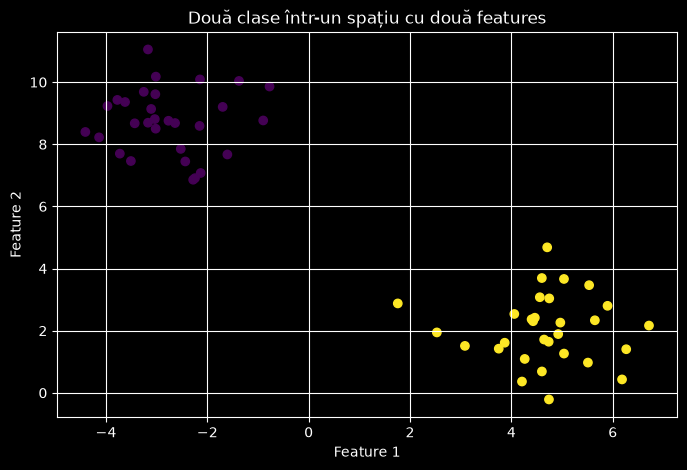

In [4]:
X_demo, y_demo = make_blobs(
    n_samples=60,
    centers=2,
    n_features=2,
    cluster_std=1.1,
    random_state=42,
)

print("Forma lui X_demo:", X_demo.shape)
print("Forma lui y_demo:", y_demo.shape)

print("\nPrimele 5 observații:")
print(X_demo[:5])

print("\nClasele primelor 5 observații:")
print(y_demo[:5])

plt.figure(figsize=(8, 5))

plt.scatter(
    X_demo[:, 0],
    X_demo[:, 1],
    c=y_demo,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Două clase într-un spațiu cu două features")
plt.grid()

plt.show()

### Cum citim graficul

Fiecare punct reprezintă o observație.

Coordonatele punctului sunt:

- poziția pe axa orizontală: valoarea primului feature;
- poziția pe axa verticală: valoarea celui de-al doilea feature.

Culoarea punctului indică clasa din `y_demo`.

Observăm două grupuri de puncte relativ separate.

În continuare vom vedea cum încearcă un SVM să traseze o frontieră între aceste două grupuri.

## 3. Frontiera de decizie

În secțiunea anterioară am reprezentat fiecare observație ca un punct într-un spațiu cu două features.

Pentru exemplul cu studenți:

- axa orizontală poate reprezenta `hours_studied`;
- axa verticală poate reprezenta `attendance`;
- fiecare punct reprezintă un student;
- culoarea punctului reprezintă clasa `passed = 0` sau `passed = 1`.

Acum vrem să găsim o regulă care să separe cele două clase.

### Ce este frontiera de decizie

Frontiera de decizie este limita care separă regiunile asociate claselor.

Într-un spațiu cu două features, frontiera poate fi reprezentată printr-o linie.

De exemplu:

- punctele aflate deasupra liniei pot fi clasificate ca `passed = 1`;
- punctele aflate sub linie pot fi clasificate ca `passed = 0`.

Pentru un student nou, modelul verifică de ce parte a frontierei se află punctul său și îi atribuie clasa corespunzătoare.

### De la linie la hiperplan

Dacă avem:

- două features, frontiera este o linie;
- trei features, frontiera este un plan;
- mai mult de trei features, folosim termenul de **hiperplan**.

Chiar dacă nu putem desena un spațiu cu zeci sau sute de dimensiuni, modelul poate lucra matematic în acel spațiu.

Formula generală a unei frontiere liniare este:

$$
w^T x + b = 0
$$

### Ce reprezintă termenii

Vectorul observației este:

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

În exemplul nostru:

- $x_1$ poate fi numărul de ore studiate;
- $x_2$ poate fi procentul de prezență.

Vectorul $w$ conține ponderile asociate features:

$$
w =
\begin{bmatrix}
w_1 \\
w_2
\end{bmatrix}
$$

Expresia poate fi scrisă și astfel:

$$
w_1x_1 + w_2x_2 + b = 0
$$

Unde:

- $w_1$ controlează contribuția primului feature;
- $w_2$ controlează contribuția celui de-al doilea feature;
- $b$ deplasează frontiera;
- împreună, $w$ și $b$ determină poziția și orientarea liniei.

### Cum este clasificată o observație

Pentru un student nou, modelul calculează:

$$
score = w^T x + b
$$

Apoi interpretează semnul rezultatului:

- dacă `score > 0`, observația este clasificată într-o parte a frontierei;
- dacă `score < 0`, observația este clasificată în cealaltă parte;
- dacă `score = 0`, observația se află exact pe frontieră.

Într-o problemă cu clasele `0` și `1`, putem interpreta simplificat:

- `score > 0` → clasa `1`;
- `score < 0` → clasa `0`.

Important:

Valoarea exactă nu reprezintă direct o probabilitate.

Ea arată poziția observației față de frontieră.

### Exemplu numeric simplificat

Presupunem că modelul a învățat:

$$
w =
\begin{bmatrix}
1 \\
1
\end{bmatrix}
$$

și:

$$
b = -5
$$

Pentru o observație:

$$
x =
\begin{bmatrix}
3 \\
4
\end{bmatrix}
$$

calculăm:

$$
score
=
1 \cdot 3
+
1 \cdot 4
-
5
$$

$$
score = 2
$$

Rezultatul este pozitiv, deci observația se află în regiunea asociată clasei pozitive.

Pentru o altă observație:

$$
x =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

obținem:

$$
score
=
1 \cdot 1
+
1 \cdot 2
-
5
$$

$$
score = -2
$$

Rezultatul este negativ, deci observația se află în cealaltă regiune.



## 4. Marginea și support vectors

În secțiunea anterioară am văzut că un SVM liniar folosește o frontieră de forma:

$$
w^T x + b = 0
$$

Această frontieră separă spațiul în două regiuni:

- observațiile aflate de o parte sunt atribuite unei clase;
- observațiile aflate de cealaltă parte sunt atribuite celeilalte clase.

Problema este că pot exista mai multe linii care separă corect aceleași puncte.

SVM nu caută orice frontieră corectă.

El caută frontiera care păstrează cea mai mare distanță posibilă față de cele mai apropiate observații din ambele clase.

Această zonă se numește **margin**.

### Cele trei linii din reprezentarea SVM

Pentru un SVM liniar, putem reprezenta:

$$
w^T x + b = 0
$$

ca frontiera de decizie.

Pe lângă aceasta, avem două linii paralele:

$$
w^T x + b = -1
$$

și:

$$
w^T x + b = 1
$$

Aceste două linii delimitează marginea.

În grafic:

- linia continuă reprezintă frontiera de decizie;
- liniile întrerupte reprezintă marginile;
- spațiul dintre liniile întrerupte reprezintă marginea totală.

### Ce sunt support vectors

Punctele aflate cel mai aproape de frontiera de decizie se numesc **support vectors**.

În cazul ideal, ele se află pe liniile:

$$
w^T x + b = -1
$$

sau:

$$
w^T x + b = 1
$$

Aceste puncte sunt importante deoarece ele determină poziția și orientarea frontierei.

Dacă mutăm un punct foarte îndepărtat de frontieră, linia poate rămâne aproape neschimbată.

Dacă mutăm un support vector, frontiera se poate modifica semnificativ.

De aici vine și numele de Support Vector Machine:

> modelul este susținut de vectorii cei mai apropiați de frontieră.

### De ce dorim o margine mare

O frontieră cu margine foarte mică poate separa perfect datele de antrenare, dar poate fi sensibilă la observații noi.

O margine mai mare oferă mai mult spațiu între clase.

Intuiția este:

> Cu cât cele două clase sunt separate mai clar, cu atât modelul are șanse mai mari să clasifice corect observații noi.

Acesta este obiectivul principal al SVM:

- separarea claselor;
- maximizarea marginii;
- folosirea punctelor cele mai apropiate pentru stabilirea frontierei.

### Ce vom face în următoarea celulă

Vom antrena un SVM liniar pe același dataset artificial folosit anterior.

Codul va:

1. antrena modelul pe `X_demo` și `y_demo`;
2. construi o rețea de puncte care acoperă întregul grafic;
3. calcula scorul SVM pentru fiecare punct din rețea;
4. desena:
   - frontiera de decizie pentru scorul `0`;
   - cele două margini pentru scorurile `-1` și `1`;
5. evidenția support vectors.

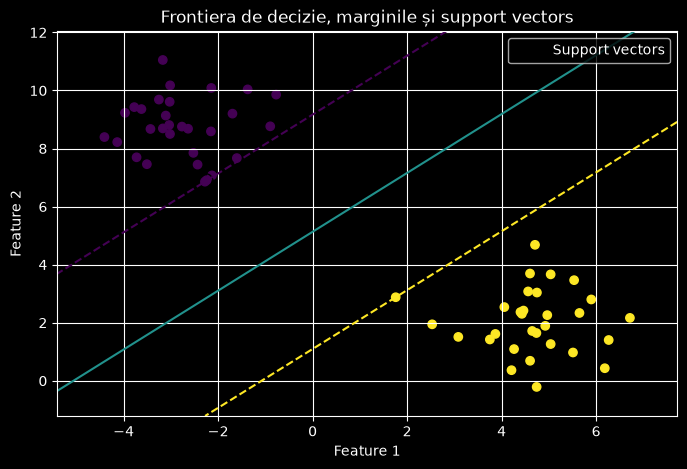

In [5]:
# Construim un SVM cu frontieră liniară
svm_demo = SVC(
    kernel="linear"
)

# Modelul învață frontiera folosind datele demonstrative
svm_demo.fit(
    X_demo,
    y_demo,
)

# Stabilim limitele graficului pe axa X
x_min = X_demo[:, 0].min() - 1
x_max = X_demo[:, 0].max() + 1

# Stabilim limitele graficului pe axa Y
y_min = X_demo[:, 1].min() - 1
y_max = X_demo[:, 1].max() + 1

# Construim o rețea densă de puncte
# pe care vom evalua modelul
xx, yy = np.meshgrid(
    np.linspace(
        x_min,
        x_max,
        300,
    ),
    np.linspace(
        y_min,
        y_max,
        300,
    ),
)

# Transformăm rețeaua într-o listă de coordonate:
# [x1, y1], [x2, y2], ...
grid_points = np.c_[
    xx.ravel(),
    yy.ravel(),
]

# Pentru fiecare punct, calculăm:
# w^T x + b
decision_values = svm_demo.decision_function(
    grid_points
)

# Refacem forma de matrice pentru desenarea contururilor
decision_values = decision_values.reshape(
    xx.shape
)

plt.figure(figsize=(8, 5))

# Desenăm observațiile inițiale
plt.scatter(
    X_demo[:, 0],
    X_demo[:, 1],
    c=y_demo,
)

# Desenăm:
# - scor -1: una dintre margini
# - scor  0: frontiera de decizie
# - scor  1: cealaltă margine
plt.contour(
    xx,
    yy,
    decision_values,
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
)

# Evidențiem support vectors
plt.scatter(
    svm_demo.support_vectors_[:, 0],
    svm_demo.support_vectors_[:, 1],
    s=140,
    facecolors="none",
    edgecolors="black",
    label="Support vectors",
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(
    "Frontiera de decizie, marginile și support vectors"
)
plt.legend()
plt.grid()

plt.show()

### Cum citim graficul

În grafic observăm:

- punctele colorate reprezintă observațiile;
- linia continuă reprezintă frontiera de decizie;
- liniile întrerupte delimitează marginea;
- punctele încercuite sunt support vectors.

Support vectors sunt observațiile cele mai apropiate de frontieră.

Ele sunt cele care influențează cel mai mult poziția liniei.

Observațiile aflate mult mai departe de frontieră contribuie mai puțin la forma finală a modelului.

### Ce înseamnă `kernel` în acest exemplu

În `SVC`, parametrul `kernel` spune modelului ce tip de relație să caute între features și clase.

Pentru moment folosim:

`kernel="linear"`

Asta înseamnă că modelul caută o frontieră liniară.

În exemplul nostru cu două features, frontiera liniară este o linie dreaptă.

Într-un spațiu cu trei features, ar fi un plan.

Într-un spațiu cu mai multe features, ar fi un hiperplan.

Prin urmare:

`SVC(kernel="linear")`

înseamnă:

> Construiește un SVM care încearcă să separe clasele folosind o frontieră liniară.

Mai târziu vom vedea și kernel-uri care permit frontiere neliniare, dar pentru acest task folosim cazul cel mai simplu.

## Task 1 - Antrenarea și interpretarea unui SVM liniar

Vom folosi dataset-ul artificial `X_demo` și `y_demo` din secțiunile anterioare.

Fiecare rând din `X_demo` reprezintă o observație cu două features:

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

Valoarea corespunzătoare din `y_demo` reprezintă clasa observației:

- clasa `0`;
- clasa `1`.

### Cerințe

1. Creează un model `SVC` cu un kernel liniar.
2. Antrenează modelul folosind `X_demo` și `y_demo`.
3. Afișează numărul total de support vectors.
4. Afișează numărul de support vectors pentru fiecare clasă.
5. Creează o observație nouă cu două features.
6. Folosește modelul pentru a prezice clasa observației.
7. Calculează scorul observației cu `decision_function()`.
8. Interpretează semnul scorului.

### Observația nouă

Vom clasifica punctul:

$$
x_{\text{nou}}
=
\begin{bmatrix}
2 \\
3
\end{bmatrix}
$$

În Python, observația trebuie reprezentată sub forma unei matrice cu un singur rând:

`[[2.0, 3.0]]`

Modelul așteaptă această structură deoarece poate primi simultan mai multe observații.

### Interpretarea scorului

Pentru clasificarea binară:

- un scor negativ plasează observația de o parte a frontierei;
- un scor pozitiv o plasează de cealaltă parte;
- un scor apropiat de `0` indică o observație apropiată de frontieră.

Scorul nu este o probabilitate.

In [ ]:
# 1. Construiește modelul cu kernel liniar
task_svm = ...

# 2. Antrenează modelul
task_svm.fit(
    ...,
    ...,
)

# 3. Numărul total de support vectors
total_support_vectors = ...

# 4. Numărul de support vectors pentru fiecare clasă
support_vectors_per_class = ...

# 5. Observația nouă
new_observation = np.array([
    [..., ...]
])

# 6. Predicția clasei
predicted_class = ...

# 7. Scorul față de frontiera de decizie
decision_score = ...

print(
    "Număr total de support vectors:",
    total_support_vectors,
)

print(
    "Support vectors pentru fiecare clasă:",
    support_vectors_per_class,
)

print(
    "Clasa prezisă:",
    predicted_class,
)

print(
    "Scorul față de frontieră:",
    decision_score,
)

<details>
<summary><strong>Hint</strong></summary>

Construiește modelul astfel:

`SVC(kernel="linear")`

Antrenează modelul cu:

`task_svm.fit(X_demo, y_demo)`

Support vectors sunt disponibile în:

`task_svm.support_vectors_`

Numărul de rânduri din această matrice reprezintă numărul total de support vectors.

Poți folosi:

`task_svm.support_vectors_.shape[0]`

Numărul de support vectors pentru fiecare clasă este disponibil direct în:

`task_svm.n_support_`

Pentru predicție folosește:

`task_svm.predict(new_observation)`

Pentru scor folosește:

`task_svm.decision_function(new_observation)`

Ambele metode returnează un array, deoarece modelul poate primi mai multe observații simultan.

Pentru prima observație, accesează elementul `[0]`.

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>task_svm = SVC(
    kernel="linear"
)

task_svm.fit(
    X_demo,
    y_demo,
)

total_support_vectors = (
    task_svm.support_vectors_.shape[0]
)

support_vectors_per_class = (
    task_svm.n_support_
)

new_observation = np.array([
    [2.0, 3.0]
])

predicted_class = task_svm.predict(
    new_observation
)[0]

decision_score = task_svm.decision_function(
    new_observation
)[0]

print(
    "Număr total de support vectors:",
    total_support_vectors,
)

print(
    "Support vectors pentru fiecare clasă:",
    support_vectors_per_class,
)

print(
    "Clasa prezisă:",
    predicted_class,
)

print(
    "Scorul față de frontieră:",
    decision_score,
)</code></pre>

</details>

## 5. Ce se întâmplă dacă datele nu pot fi separate printr-o linie?

Unele probleme nu pot fi rezolvate printr-o frontieră liniară în spațiul inițial.

De exemplu:

- o clasă poate fi concentrată în centru;
- cealaltă clasă poate forma un cerc în jurul ei.

Într-un astfel de caz, o singură linie nu poate separa corect clasele.

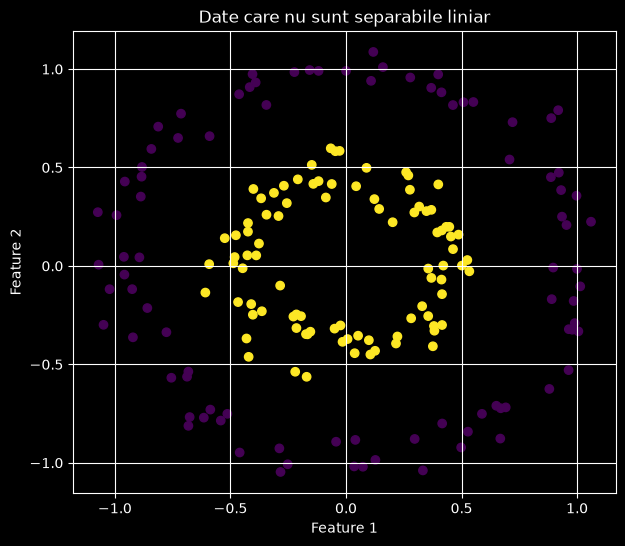

In [6]:
X_circles, y_circles = make_circles(
    n_samples=180,
    noise=0.08,
    factor=0.45,
    random_state=42,
)

plt.figure(figsize=(7, 6))
plt.scatter(
    X_circles[:, 0],
    X_circles[:, 1],
    c=y_circles,
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Date care nu sunt separabile liniar")
plt.grid()
plt.show()

## 6. Spații de trăsături cu dimensiuni superioare

În exemplul anterior avem două clase dispuse aproximativ sub forma unor cercuri:

- punctele unei clase se află aproape de centru;
- punctele celeilalte clase se află mai departe de centru.

Fiecare observație este descrisă prin două features:

$$ x_1 $$ și: $$ x_2 $$

Acestea reprezintă coordonatele punctului în plan.

Problema este că, în acest spațiu cu două dimensiuni, nu putem trasa o singură linie dreaptă care să separe punctele din centru de punctele aflate în exterior.

### Ce informație ne-ar ajuta

Privind graficul, diferența importantă dintre cele două clase nu este doar poziția pe axa $x_1$ sau poziția pe axa $x_2$.

Diferența importantă este:

> Cât de departe se află fiecare punct față de centrul planului?

Punctele clasei interioare sunt mai aproape de centru.

Punctele clasei exterioare sunt mai departe de centru.

Așadar, putem construi un feature nou care să reprezinte această distanță.

### Distanța față de centru

Pentru un punct cu coordonatele:

$$
(x_1, x_2)
$$

distanța față de centrul planului, adică față de punctul $(0, 0)$, se calculează cu formula:

$$
d =
\sqrt{x_1^2 + x_2^2}
$$

Formula vine din teorema lui Pitagora:

- $x_1$ reprezintă distanța pe orizontală;
- $x_2$ reprezintă distanța pe verticală;
- $d$ reprezintă distanța directă până la centru.

### De ce folosim pătratele

Ridicăm coordonatele la pătrat din două motive.

Primul motiv este că vrem ca valorile negative și pozitive să contribuie la fel.

De exemplu:

$$
(-0.8)^2 = 0.64
$$

și:

$$
0.8^2 = 0.64
$$

Un punct aflat la stânga centrului și unul aflat la dreapta centrului pot fi la aceeași distanță de centru.

Al doilea motiv este că pătratele permit combinarea deplasării pe cele două axe prin teorema lui Pitagora.

### De ce nu avem nevoie de radical

Pentru clasificare, putem folosi direct:

$$
z = x_1^2 + x_2^2
$$

Aceasta este distanța față de centru ridicată la pătrat:

$$
z = d^2
$$

Nu avem nevoie să calculăm radicalul deoarece ordinea punctelor rămâne aceeași:

- dacă un punct are distanță mică, va avea și $z$ mic;
- dacă un punct are distanță mare, va avea și $z$ mare.

Radicalul ar schimba valorile numerice, dar nu ar schimba care punct este mai aproape sau mai departe de centru.

Prin urmare, folosim forma mai simplă:

$$
z = x_1^2 + x_2^2
$$

### Exemplu numeric pentru un punct apropiat de centru

Pentru punctul:

$$
x =
\begin{bmatrix}
0.2 \\
0.3
\end{bmatrix}
$$

calculăm:

$$
z
=
0.2^2 + 0.3^2
$$

$$
z
=
0.04 + 0.09
$$

$$
z = 0.13
$$

Valoarea este mică, ceea ce arată că punctul este apropiat de centru.

### Exemplu numeric pentru un punct mai îndepărtat

Pentru punctul:

$$
x =
\begin{bmatrix}
0.9 \\
0.8
\end{bmatrix}
$$

calculăm:

$$
z
=
0.9^2 + 0.8^2
$$

$$
z
=
0.81 + 0.64
$$

$$
z = 1.45
$$

Valoarea este mai mare, ceea ce arată că punctul este mai îndepărtat de centru.

### Ce am obținut prin feature-ul nou

Inițial, fiecare observație era reprezentată prin:

$$
(x_1, x_2)
$$

După transformare, putem folosi și feature-ul:

$$
z = x_1^2 + x_2^2
$$

Observația poate fi reprezentată astfel:

$$
(x_1, x_2, z)
$$

Am adăugat o a treia dimensiune care descrie distanța față de centru.

### De ce devine problema mai simplă

În spațiul inițial, cele două clase formau cercuri și nu puteau fi separate printr-o linie.

După calcularea lui $z$:

- punctele din cercul interior au valori mai mici;
- punctele din cercul exterior au valori mai mari.

Putem separa clasele folosind un simplu prag:

$$
z < prag
$$

pentru clasa interioară și:

$$
z > prag
$$

pentru clasa exterioară.

Așadar, problema neliniară din spațiul inițial devine o problemă liniară în noua reprezentare.

### Limitarea practică

În exemplul nostru am construit manual un singur feature:

$$
z = x_1^2 + x_2^2
$$

În probleme reale, transformarea poate produce:

- zeci de features noi;
- sute de features noi;
- mii sau milioane de combinații.

Construirea și stocarea explicită a tuturor acestor features poate fi costisitoare.

Aici apare ideea de **Kernel Trick**:

> SVM poate lucra ca și cum datele ar fi fost transformate într-un spațiu mai mare, fără să construiască explicit toate noile features.

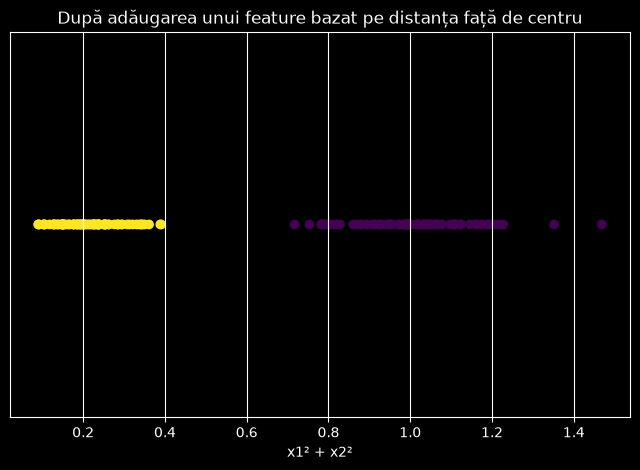

In [7]:
radius_feature = (
    X_circles[:, 0] ** 2
    + X_circles[:, 1] ** 2
)

plt.figure(figsize=(8, 5))
plt.scatter(
    radius_feature,
    np.zeros_like(radius_feature),
    c=y_circles,
)
plt.xlabel("x1² + x2²")
plt.yticks([])
plt.title("După adăugarea unui feature bazat pe distanța față de centru")
plt.grid()
plt.show()

## 7. Kernel Trick

În secțiunea anterioară am văzut că datele cu formă circulară nu pot fi separate printr-o singură linie în spațiul inițial.

Am rezolvat problema construind manual un feature nou:

$$
z = x_1^2 + x_2^2
$$

Acest feature ne spune cât de departe se află un punct față de centrul planului.

După transformare:

- punctele din cercul interior au valori mici pentru $z$;
- punctele din cercul exterior au valori mai mari pentru $z$;
- clasele devin mai ușor de separat.

Ideea generală este:

> O problemă care nu este liniară în spațiul inițial poate deveni liniară după transformarea datelor.

### De ce transformarea manuală poate deveni dificilă

Pentru două features, $x_1$ și $x_2$, putem construi manual câteva features noi:

$$
x_1^2
$$

$$
x_2^2
$$

$$
x_1x_2
$$

Să luăm un punct simplu:

$$
x =
\begin{bmatrix}
2 \\
3
\end{bmatrix}
$$

Atunci:

$$
x_1^2 = 2^2 = 4
$$

$$
x_2^2 = 3^2 = 9
$$

$$
x_1x_2 = 2 \cdot 3 = 6
$$

Punctul inițial:

$$
(2, 3)
$$

poate deveni:

$$
(2, 3, 4, 9, 6)
$$

Am pornit de la două features și am ajuns la cinci.

Pentru două features, acest lucru este încă simplu.

Dar dacă avem:

- 100 de features inițiale;
- produse între ele;
- pătrate;
- puteri mai mari;

numărul noilor features poate crește foarte mult.

Problema nu este doar calculul.

Trebuie și să stocăm toate aceste coloane într-o matrice mult mai mare.

### Ce face un kernel

Un kernel este o funcție care compară două observații.

Îl notăm astfel:

$$
K(x_i, x_j)
$$

Să explicăm fiecare simbol:

- $K$ este funcția kernel;
- $x_i$ este o observație din dataset;
- $x_j$ este o altă observație din dataset;
- indicii $i$ și $j$ ne ajută doar să diferențiem observațiile;
- rezultatul lui $K(x_i, x_j)$ este un singur număr.

De exemplu, dacă avem doi studenți reprezentați prin câte două features:

$$
x_i =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

și:

$$
x_j =
\begin{bmatrix}
3 \\
4
\end{bmatrix}
$$

atunci kernel-ul primește cei doi vectori și returnează un număr:

$$
K(x_i, x_j)
$$

Modul în care este calculat acel număr depinde de kernel-ul ales.

Rezultatul nu este o probabilitate.

Este o valoare folosită de SVM pentru a compara cele două observații.

### Ideea Kernel Trick

Fără Kernel Trick, procesul ar fi:

1. construim manual features noi;
2. transformăm fiecare observație;
3. stocăm toate valorile noi;
4. antrenăm modelul în spațiul transformat.

Cu Kernel Trick:

1. păstrăm observațiile în forma inițială;
2. kernel-ul calculează direct comparațiile necesare;
3. modelul se comportă ca și cum observațiile ar fi fost transformate;
4. nu mai construim explicit toate coloanele noi.

Așadar:

> Kernel Trick permite unui SVM să lucreze indirect într-un spațiu cu mai multe dimensiuni, fără să construiască explicit toate features acelui spațiu.

## Kernel liniar

Kernel-ul liniar folosește produsul scalar dintre două observații:

$$
K(x_i, x_j) = x_i^T x_j
$$

Înainte să calculăm formula, trebuie să explicăm simbolul:

$$
x_i^T
$$

Litera $T$ nu este o putere.

$T$ înseamnă **transpus**.

Transpunerea transformă un vector coloană într-un vector linie.

Dacă:

$$
x_i =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

atunci:

$$
x_i^T =
\begin{bmatrix}
1 & 2
\end{bmatrix}
$$

Am trecut de la:

- două valori scrise vertical;
- la aceleași două valori scrise orizontal.

Acest lucru ne permite să înmulțim vectorii:

$$
x_i^T x_j
$$

Presupunem:

$$
x_i =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

și:

$$
x_j =
\begin{bmatrix}
3 \\
4
\end{bmatrix}
$$

Mai întâi transpunem primul vector:

$$
x_i^T =
\begin{bmatrix}
1 & 2
\end{bmatrix}
$$

Apoi calculăm:

$$
x_i^T x_j
=
\begin{bmatrix}
1 & 2
\end{bmatrix}
\begin{bmatrix}
3 \\
4
\end{bmatrix}
$$

Înmulțim valorile aflate pe aceleași poziții:

$$
1 \cdot 3
$$

și:

$$
2 \cdot 4
$$

Apoi adunăm rezultatele:

$$
x_i^T x_j
=
1 \cdot 3
+
2 \cdot 4
$$

$$
x_i^T x_j
=
3 + 8
$$

$$
x_i^T x_j = 11
$$

Așadar:

$$
K(x_i, x_j) = 11
$$

Acest calcul se numește **produs scalar**.

Pe scurt:

> Produsul scalar înmulțește features corespunzătoare și adună rezultatele.

Când folosim:

`kernel="linear"`

SVM folosește acest tip de comparație și caută o frontieră liniară.

În două dimensiuni, frontiera este o linie dreaptă.

## Kernel polinomial

Kernel-ul polinomial permite comparații care includ produse și puteri ale features.

O formă simplificată este:

$$
K(x_i, x_j)
=
(x_i^T x_j + c)^d
$$

Explicăm fiecare termen:

- $K(x_i, x_j)$ este rezultatul kernel-ului;
- $x_i$ și $x_j$ sunt cele două observații;
- $x_i^T x_j$ este produsul scalar;
- $c$ este o constantă adăugată rezultatului;
- $d$ este gradul polinomului;
- paranteza este ridicată la puterea $d$.

Să folosim exemplul anterior:

$$
x_i^T x_j = 11
$$

Presupunem:

$$
c = 1
$$

și:

$$
d = 2
$$

Înlocuim valorile:

$$
K(x_i, x_j)
=
(11 + 1)^2
$$

Calculăm mai întâi paranteza:

$$
11 + 1 = 12
$$

Apoi ridicăm rezultatul la puterea a doua:

$$
12^2 = 144
$$

Prin urmare:

$$
K(x_i, x_j) = 144
$$

Un astfel de kernel permite modelului să surprindă indirect relații precum:

$$
x_1^2
$$

$$
x_2^2
$$

$$
x_1x_2
$$

fără să construim manual fiecare feature.

## Kernel RBF

Kernel-ul RBF este util atunci când clasele au forme neliniare.

În exemplul nostru, clasele formează două cercuri.

Formula kernel-ului RBF este:

$$
K(x_i, x_j)
=
\exp
\left(
-\gamma
\lVert x_i - x_j \rVert^2
\right)
$$

Formula pare complicată, așa că o descompunem.

### Ce înseamnă fiecare termen

- $K(x_i, x_j)$ este rezultatul kernel-ului;
- $x_i$ este prima observație;
- $x_j$ este a doua observație;
- $x_i - x_j$ reprezintă diferența dintre cele două observații;
- simbolul $\lVert \cdot \rVert$ reprezintă lungimea sau distanța;
- exponentul $2$ înseamnă că folosim distanța ridicată la pătrat;
- $\gamma$ se citește „gamma” și controlează cât de repede scade similaritatea;
- semnul minus face ca punctele îndepărtate să primească valori mici;
- $\exp$ reprezintă funcția exponențială.


### Pasul 1 - Diferența dintre observații

Presupunem:

$$
x_i =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

și:

$$
x_j =
\begin{bmatrix}
2 \\
4
\end{bmatrix}
$$

Calculăm diferența:

$$
x_i - x_j
=
\begin{bmatrix}
1 - 2 \\
2 - 4
\end{bmatrix}
$$

$$
x_i - x_j
=
\begin{bmatrix}
-1 \\
-2
\end{bmatrix}
$$

### Pasul 2 - Distanța pătratică

Notația:

$$
\lVert x_i - x_j \rVert^2
$$

înseamnă:

> Ridicăm fiecare diferență la pătrat și adunăm rezultatele.

În exemplul nostru:

$$
\lVert x_i - x_j \rVert^2
=
(-1)^2 + (-2)^2
$$

$$
\lVert x_i - x_j \rVert^2
=
1 + 4
$$

$$
\lVert x_i - x_j \rVert^2
=
5
$$

### Pasul 3 - Alegem o valoare pentru gamma

Presupunem, doar pentru exemplu:

$$
\gamma = 0.5
$$

Atunci exponentul devine:

$$
-\gamma
\lVert x_i - x_j \rVert^2
$$

$$
=
-0.5 \cdot 5
$$

$$
=
-2.5
$$

### Pasul 4 - Aplicăm funcția exponențială

Obținem:

$$
K(x_i, x_j)
=
\exp(-2.5)
$$

Aproximativ:

$$
K(x_i, x_j)
\approx 0.082
$$

Valoarea este relativ mică, deoarece cele două observații sunt destul de îndepărtate.

### Ce se întâmplă pentru două puncte identice

Dacă:

$$
x_i = x_j
$$

atunci:

$$
x_i - x_j = 0
$$

Distanța pătratică este:

$$
\lVert x_i - x_j \rVert^2 = 0
$$

Kernel-ul devine:

$$
K(x_i, x_j)
=
\exp(0)
$$

$$
K(x_i, x_j) = 1
$$

Așadar, două puncte identice primesc similaritatea maximă.

### Interpretarea rezultatului RBF

Rezultatul kernel-ului RBF este între valori apropiate de `0` și `1`.

- valoare apropiată de `1` → observațiile sunt apropiate;
- valoare apropiată de `0` → observațiile sunt îndepărtate.

Important:

Această valoare nu este probabilitatea ca observațiile să aparțină aceleiași clase.

Este o măsură de similaritate folosită de SVM.

## Ce face parametrul `gamma`

`gamma` controlează cât de repede scade similaritatea odată cu distanța.

Să păstrăm aceeași distanță:

$$
\lVert x_i - x_j \rVert^2 = 5
$$

### Gamma mic

Dacă:

$$
\gamma = 0.1
$$

atunci:

$$
-\gamma \cdot 5
=
-0.5
$$

$$
\exp(-0.5)
\approx 0.61
$$

Similaritatea rămâne relativ mare.

Influența unui punct se întinde pe o zonă mai largă.

### Gamma mare

Dacă:

$$
\gamma = 2
$$

atunci:

$$
-\gamma \cdot 5
=
-10
$$

$$
\exp(-10)
\approx 0.000045
$$

Similaritatea devine foarte mică.

Influența unui punct rămâne concentrată într-o zonă mică.

Prin urmare:

- `gamma` mic → influență mai largă și frontieră mai netedă;
- `gamma` mare → influență locală și frontieră mai flexibilă.

În exemplul nostru folosim:

`gamma="scale"`

Aceasta înseamnă că `scikit-learn` calculează automat o valoare pe baza:

- numărului de features;
- variației valorilor din dataset.

Nu vom calcula sau ajusta manual această valoare în sesiunea curentă.


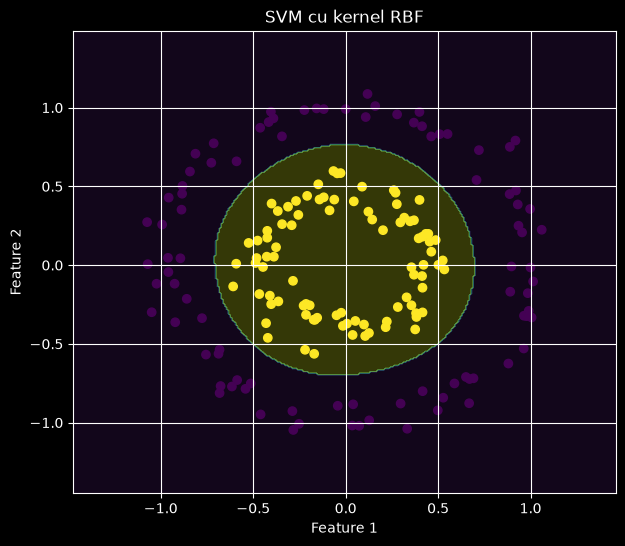

In [8]:
rbf_model = SVC(kernel="rbf", gamma="scale")
rbf_model.fit(X_circles, y_circles)

x_min, x_max = X_circles[:, 0].min() - 0.4, X_circles[:, 0].max() + 0.4
y_min, y_max = X_circles[:, 1].min() - 0.4, X_circles[:, 1].max() + 0.4

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

predicted_regions = rbf_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(
    xx,
    yy,
    predicted_regions,
    alpha=0.25,
)
plt.scatter(
    X_circles[:, 0],
    X_circles[:, 1],
    c=y_circles,
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM cu kernel RBF")
plt.grid()
plt.show()

## Task 2 - Compararea unui kernel liniar cu un kernel RBF

Vom folosi dataset-ul `X_circles` și clasele `y_circles` construite anterior.

Dataset-ul conține două clase dispuse aproximativ sub forma a două cercuri:

- o clasă formează cercul interior;
- cealaltă clasă formează cercul exterior.

Am observat că aceste clase nu pot fi separate corect printr-o singură linie dreaptă.

În acest task vom compara:

- un SVM cu `kernel="linear"`;
- un SVM cu `kernel="rbf"`.

### Ce vrem să verificăm

Kernel-ul liniar caută o frontieră dreaptă.

Kernel-ul RBF poate construi o frontieră neliniară, adaptată formei circulare a datelor.

Vom împărți dataset-ul în:

- train set - folosit pentru antrenarea modelelor;
- test set - folosit pentru evaluarea lor pe observații nevăzute.

### Cerințe

1. Împarte `X_circles` și `y_circles` în train și test.
2. Păstrează 25% dintre observații pentru test.
3. Creează un model SVM cu `kernel="linear"`.
4. Antrenează modelul liniar pe train set.
5. Prezice clasele observațiilor din test set.
6. Calculează accuracy pentru modelul liniar.
7. Creează un model SVM cu `kernel="rbf"`.
8. Folosește `gamma="scale"`.
9. Antrenează modelul RBF pe același train set.
10. Prezice clasele aceluiași test set.
11. Calculează accuracy pentru modelul RBF.
12. Compară cele două rezultate.

### Întrebări de interpretare

După rularea codului, răspunde la următoarele întrebări:

1. Care model obține un accuracy mai mare?
2. De ce are modelul liniar dificultăți?
3. Ce proprietate a kernel-ului RBF îl ajută în acest exemplu?
4. Înseamnă rezultatul că RBF este întotdeauna mai bun decât kernel-ul liniar?

In [ ]:
# 1. Împărțim datele în train și test
X_train_circles, X_test_circles, y_train_circles, y_test_circles = (
    train_test_split(
        ...,
        ...,
        test_size=...,
        random_state=42,
        stratify=...,
    )
)

# 2. Construim modelul cu kernel liniar
linear_circle_model = SVC(
    kernel=...
)

# 3. Antrenăm modelul liniar
linear_circle_model.fit(
    ...,
    ...,
)

# 4. Facem predicții pe test set
linear_predictions = ...

# 5. Calculăm accuracy pentru modelul liniar
linear_accuracy = ...

# 6. Construim modelul cu kernel RBF
rbf_circle_model = SVC(
    kernel=...,
    gamma=...,
)

# 7. Antrenăm modelul RBF
rbf_circle_model.fit(
    ...,
    ...,
)

# 8. Facem predicții pe același test set
rbf_predictions = ...

# 9. Calculăm accuracy pentru modelul RBF
rbf_accuracy = ...

print(
    "Accuracy pentru kernel-ul liniar:",
    linear_accuracy,
)

print(
    "Accuracy pentru kernel-ul RBF:",
    rbf_accuracy,
)

<details>
<summary><strong>Hint</strong></summary>

Pentru împărțirea datelor folosește:

<pre><code>train_test_split(
    X_circles,
    y_circles,
    test_size=0.25,
    random_state=42,
    stratify=y_circles,
)</code></pre>

Modelul liniar se construiește cu:

<pre><code>SVC(kernel="linear")</code></pre>

Modelul RBF se construiește cu:

<pre><code>SVC(
    kernel="rbf",
    gamma="scale",
)</code></pre>

Ambele modele trebuie antrenate folosind aceleași date:

<pre><code>model.fit(
    X_train_circles,
    y_train_circles,
)</code></pre>

Predicțiile se obțin cu:

<pre><code>model.predict(X_test_circles)</code></pre>

Accuracy se calculează prin:

<pre><code>accuracy_score(
    y_test_circles,
    predictions,
)</code></pre>

Este important să folosim același train set și același test set pentru ambele modele.

Altfel, comparația nu ar fi corectă.

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>X_train_circles, X_test_circles, y_train_circles, y_test_circles = (
    train_test_split(
        X_circles,
        y_circles,
        test_size=0.25,
        random_state=42,
        stratify=y_circles,
    )
)

linear_circle_model = SVC(
    kernel="linear"
)

linear_circle_model.fit(
    X_train_circles,
    y_train_circles,
)

linear_predictions = linear_circle_model.predict(
    X_test_circles
)

linear_accuracy = accuracy_score(
    y_test_circles,
    linear_predictions,
)

rbf_circle_model = SVC(
    kernel="rbf",
    gamma="scale",
)

rbf_circle_model.fit(
    X_train_circles,
    y_train_circles,
)

rbf_predictions = rbf_circle_model.predict(
    X_test_circles
)

rbf_accuracy = accuracy_score(
    y_test_circles,
    rbf_predictions,
)

print(
    "Accuracy pentru kernel-ul liniar:",
    linear_accuracy,
)

print(
    "Accuracy pentru kernel-ul RBF:",
    rbf_accuracy,
)</code></pre>

</details>

# Partea a II-a - De la text la features

## 8. Problema clasificării textului

Modelele de machine learning nu pot folosi direct propoziții.

Textul trebuie transformat într-o reprezentare numerică.

În această sesiune clasificăm mesaje trimise de studenți în două clase:

- `academic` - cursuri, teme, laboratoare, examene, proiecte și notare;
- `administrative` - taxe, adeverințe, înscrieri, conturi și documente.

Vom folosi **Bag of Words**.

## 9. Bag of Words

Bag of Words construiește un vocabular din cuvintele întâlnite în texte.

Fiecare cuvânt devine un feature.

Exemplu:

- mesajul 1: `tema laborator`
- mesajul 2: `taxa student`

Vocabularul poate fi:

$$
[tema,\ laborator,\ taxa,\ student]
$$

Reprezentările numerice devin:

$$
tema\ laborator
\rightarrow
[1,\ 1,\ 0,\ 0]
$$

$$
taxa\ student
\rightarrow
[0,\ 0,\ 1,\ 1]
$$

Modelul nu vede propoziții, ci vectori numerici.

Bag of Words ignoră în forma sa simplă ordinea cuvintelor și păstrează doar aparițiile sau frecvențele lor.

## 10. Exemplu manual cu `CountVectorizer`

In [9]:
example_texts = [
    "tema laborator",
    "taxa student",
    "tema pentru laborator",
]

example_vectorizer = CountVectorizer()
example_matrix = example_vectorizer.fit_transform(
    example_texts
)

print("Vocabular:")
print(example_vectorizer.get_feature_names_out())

print("\nMatricea Bag of Words:")
print(example_matrix.toarray())

Vocabular:
['laborator' 'pentru' 'student' 'taxa' 'tema']

Matricea Bag of Words:
[[1 0 0 0 1]
 [0 0 1 1 0]
 [1 1 0 0 1]]


### Interpretarea matricei

Fiecare:

- rând reprezintă un mesaj;
- coloană reprezintă un cuvânt din vocabular;
- valoare reprezintă numărul de apariții al cuvântului în mesaj.

Dacă vocabularul conține 2.000 de cuvinte, fiecare mesaj este reprezentat într-un spațiu cu 2.000 de dimensiuni.

Majoritatea valorilor sunt `0`, deoarece un mesaj folosește doar o parte mică din vocabular.

De aceea matricea este stocată în format **sparse**.

## Task 3 - Inspectarea unei reprezentări Bag of Words

Folosește următoarele mesaje:

- `proiectul trebuie încărcat pe platformă`
- `nu mă pot autentifica pe platformă`
- `care este termenul pentru proiect`

Cerințe:

1. creează un obiect `CountVectorizer`;
2. aplică `fit_transform()` pe lista de mesaje;
3. afișează vocabularul cu `get_feature_names_out()`;
4. afișează matricea numerică folosind `.toarray()`;
5. identifică un cuvânt care apare în mai multe mesaje.

In [ ]:
task_messages = [
    "proiectul trebuie încărcat pe platformă",
    "nu mă pot autentifica pe platformă",
    "care este termenul pentru proiect",
]

task_vectorizer = ...
task_matrix = ...

print("Vocabular:")
print(...)

print("\nMatrice:")
print(...)

<details>
<summary><strong>Hint</strong></summary>

Creează vectorizatorul:

<pre><code>task_vectorizer = CountVectorizer()</code></pre>

Construiește vocabularul și matricea:

<pre><code>task_matrix = task_vectorizer.fit_transform(task_messages)</code></pre>

Pentru afișare folosește:

<pre><code>task_vectorizer.get_feature_names_out()
task_matrix.toarray()</code></pre>

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>task_vectorizer = CountVectorizer()

task_matrix = task_vectorizer.fit_transform(
    task_messages
)

print("Vocabular:")
print(
    task_vectorizer.get_feature_names_out()
)

print("\nMatrice:")
print(
    task_matrix.toarray()
)</code></pre>

Cuvântul `platformă` apare în primele două mesaje.

</details>

## 11. Încărcarea dataset-ului

Dataset-ul conține:

- `message_id` - identificatorul mesajului;
- `text` - conținutul mesajului;
- `label` - clasa `academic` sau `administrative`;
- `topic` - subiectul mai specific al mesajului.

Pentru model vom folosi:

- `text` ca input;
- `label` ca target.

Coloana `topic` este păstrată doar pentru explorarea dataset-ului.

In [10]:
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "ipworkshop/ipw2026-introduction-to-machine-learning/"
    "main/data/student_messages_svm_bow.csv"
)

df = pd.read_csv(DATA_URL)

df.head()

HTTPError: HTTP Error 404: Not Found

In [11]:
print("Dimensiunea dataset-ului:", df.shape)

print("\nDistribuția claselor:")
print(df["label"].value_counts())

print("\nExemple de topicuri:")
print(df["topic"].value_counts())

NameError: name 'df' is not defined

## 12. Separarea în train și test

Vom păstra 20% dintre mesaje pentru test.

Folosim:

- `random_state=42` pentru rezultate reproductibile;
- `stratify=y` pentru a păstra proporția claselor în ambele seturi.

Este important ca vectorizatorul să învețe vocabularul doar din train.

In [ ]:
X = df["text"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Mesaje train:", len(X_train_text))
print("Mesaje test:", len(X_test_text))

## 13. De ce folosim `fit_transform()` doar pe train

După împărțirea dataset-ului, avem:

- `X_train_text` - mesajele folosite pentru antrenare;
- `X_test_text` - mesajele păstrate pentru evaluare.

Bag of Words trebuie să construiască un vocabular.

Acest vocabular stabilește coloanele matricei numerice.

De exemplu, presupunem că în train avem mesajele:

- `tema laborator`
- `taxa student`

Din aceste mesaje, `CountVectorizer` poate construi vocabularul:

$$
[tema,\ laborator,\ taxa,\ student]
$$

Fiecare cuvânt devine o coloană.

Matricea pentru train ar putea arăta astfel:

| mesaj | laborator | student | taxa | tema |
|---|---:|---:|---:|---:|
| `tema laborator` | 1 | 0 | 0 | 1 |
| `taxa student` | 0 | 1 | 1 | 0 |

### Ce face `fit_transform()`

Când apelăm:

`vectorizer.fit_transform(X_train_text)`

se întâmplă două lucruri.

#### `fit()`

`fit()` citește mesajele din train și construiește vocabularul.

Cu alte cuvinte, decide:

- ce cuvinte devin features;
- în ce ordine apar coloanele.

#### `transform()`

`transform()` ia mesajele și le transformă în vectori numerici folosind vocabularul deja construit.

Prin urmare:

`fit_transform()`

înseamnă:

> Construiește vocabularul din train și transformă train set-ul folosind acel vocabular.

### Ce facem pe test

Pe test folosim doar:

`vectorizer.transform(X_test_text)`

Nu mai construim un vocabular nou.

Folosim exact aceleași coloane ca în train.

Presupunem că în test avem mesajul:

`tema proiect`

Vocabularul construit din train este în continuare:

$$
[laborator,\ student,\ taxa,\ tema]
$$

Cuvântul `tema` există în vocabular, deci primește valoarea `1`.

Cuvântul `proiect` nu a apărut în train și nu există în vocabular.

El este ignorat.

Reprezentarea mesajului devine:

| mesaj | laborator | student | taxa | tema |
|---|---:|---:|---:|---:|
| `tema proiect` | 0 | 0 | 0 | 1 |

Acest lucru este important deoarece modelul a fost antrenat pe exact aceste patru coloane.

Test set-ul trebuie să folosească aceeași structură.

### De ce nu folosim `fit_transform()` și pe test

Dacă am apela:

`fit_transform(X_test_text)`

și pe test, s-ar construi un vocabular nou.

De exemplu, testul ar putea produce coloanele:

$$
[proiect,\ tema]
$$

Aceste coloane nu mai corespund cu vocabularul din train.

Modelul a învățat pe:

$$
[laborator,\ student,\ taxa,\ tema]
$$

dar ar primi la test:

$$
[proiect,\ tema]
$$

Numărul și sensul coloanelor ar fi diferite.

Asta ar face evaluarea incorectă.

În plus, dacă folosim testul pentru a decide vocabularul, lăsăm informație din test să influențeze pregătirea datelor.

Acest fenomen se numește **data leakage**.

Regula corectă este:

- `fit_transform()` pe train;
- `transform()` pe test;
- același vocabular pentru ambele seturi.

### Inspectarea vocabularului construit

După ce apelăm:

`vectorizer.fit_transform(X_train_text)`

obiectul `vectorizer` păstrează vocabularul învățat din mesajele de train.

Putem vedea cuvintele care au devenit features folosind:

`vectorizer.get_feature_names_out()`

Metoda returnează cuvintele în ordinea în care apar coloanele matricei Bag of Words.

De exemplu, dacă vocabularul este:

`["laborator", "student", "taxa", "tema"]`

atunci:

- prima coloană reprezintă `laborator`;
- a doua coloană reprezintă `student`;
- a treia coloană reprezintă `taxa`;
- a patra coloană reprezintă `tema`.


## Task 3 - Clasificarea mesajelor cu Bag of Words și SVM

Vom construi un clasificator complet pentru mesajele studenților.

Dataset-ul conține două clase:

- `academic` - mesaje despre cursuri, teme, laboratoare, examene, proiecte și notare;
- `administrative` - mesaje despre taxe, adeverințe, înscrieri, conturi și documente.

Vom transforma textele în vectori numerici folosind Bag of Words.

Apoi vom compara două modele:

- `LinearSVC` - un SVM liniar;
- `SVC(kernel="rbf")` - un SVM care folosește kernel-ul RBF.

### De ce comparăm cele două modele

Bag of Words transformă fiecare cuvânt într-un feature.

Dacă vocabularul conține 500 de cuvinte, fiecare mesaj este reprezentat într-un spațiu cu 500 de dimensiuni.

Într-un astfel de spațiu:

- datele pot fi deja suficient de ușor de separat printr-o frontieră liniară;
- un model liniar poate funcționa foarte bine;
- un kernel neliniar nu este automat mai bun.

Kernel-ul RBF ne permite totuși să verificăm dacă o frontieră mai flexibilă ajută în cazul acestui dataset.

### Cerințe

1. Creează un obiect `CountVectorizer`.
2. Construiește vocabularul doar din `X_train_text`.
3. Transformă mesajele de train cu `fit_transform()`.
4. Transformă mesajele de test cu `transform()`.
5. Afișează:
   - numărul de cuvinte din vocabular;
   - forma matricei pentru train;
   - forma matricei pentru test.
6. Creează și antrenează un model `LinearSVC`.
7. Calculează predicțiile și accuracy pentru modelul liniar.
8. Creează și antrenează un model `SVC` cu:
   - `kernel="rbf"`;
   - `gamma="scale"`.
9. Calculează predicțiile și accuracy pentru modelul RBF.
10. Compară rezultatele celor două modele.
11. Afișează raportul de clasificare pentru modelul cu rezultatul mai bun.
12. Testează modelul mai bun pe câteva mesaje noi.


In [ ]:
# 1. Construim vectorizatorul
vectorizer = ...

# 2. Construim vocabularul doar din train
# și transformăm mesajele de train
X_train_bow = ...

# 3. Transformăm testul folosind același vocabular
X_test_bow = ...

# 4. Inspectăm reprezentarea Bag of Words
feature_names = ...

print(
    "Număr de cuvinte în vocabular:",
    ...
)

print(
    "Forma matricei train:",
    ...
)

print(
    "Forma matricei test:",
    ...
)

# 5. Construim modelul liniar
linear_text_model = ...

# 6. Antrenăm modelul liniar
linear_text_model.fit(
    ...,
    ...,
)

# 7. Predicții și accuracy pentru modelul liniar
linear_text_predictions = ...

linear_text_accuracy = ...

# 8. Construim modelul cu kernel RBF
rbf_text_model = SVC(
    kernel=...,
    gamma=...,
)

# 9. Antrenăm modelul RBF
rbf_text_model.fit(
    ...,
    ...,
)

# 10. Predicții și accuracy pentru modelul RBF
rbf_text_predictions = ...

rbf_text_accuracy = ...

print(
    "\nAccuracy LinearSVC:",
    linear_text_accuracy,
)

print(
    "Accuracy SVC cu kernel RBF:",
    rbf_text_accuracy,
)

# 11. Alegem modelul cu accuracy mai mare
if ...:
    best_model = ...
    best_predictions = ...
    best_model_name = ...
else:
    best_model = ...
    best_predictions = ...
    best_model_name = ...

print(
    "\nModelul cu rezultatul mai bun:",
    best_model_name,
)

print("\nRaport de clasificare:")

print(
    ...
)

# 12. Mesaje noi
new_messages = [
    "Nu înțeleg cerința proiectului pentru laborator",
    "Cum pot obține o adeverință de student?",
    "Când se afișează rezultatele examenului?",
    "Am plătit taxa dar nu apare în cont",
]

# Folosim același vectorizator
new_messages_bow = ...

# Folosim modelul cu rezultatul mai bun
new_predictions = ...

for message, prediction in zip(
    new_messages,
    new_predictions,
):
    print("\nMesaj:", message)
    print("Predicție:", prediction)

<details>
<summary><strong>Hint</strong></summary>

Pentru Bag of Words:

<pre><code>vectorizer = CountVectorizer()

X_train_bow = vectorizer.fit_transform(
    X_train_text
)

X_test_bow = vectorizer.transform(
    X_test_text
)</code></pre>

Vocabularul poate fi accesat cu:

<pre><code>feature_names = vectorizer.get_feature_names_out()</code></pre>

Numărul de features este:

<pre><code>len(feature_names)</code></pre>

Modelul liniar:

<pre><code>linear_text_model = LinearSVC()</code></pre>

Modelul cu RBF:

<pre><code>rbf_text_model = SVC(
    kernel="rbf",
    gamma="scale",
)</code></pre>

Ambele modele trebuie antrenate pe:

<pre><code>X_train_bow
y_train</code></pre>

și evaluate pe:

<pre><code>X_test_bow
y_test</code></pre>

Pentru a compara modelele:

<pre><code>if linear_text_accuracy >= rbf_text_accuracy:</code></pre>

Pentru mesajele noi trebuie folosit:

<pre><code>vectorizer.transform(new_messages)</code></pre>

Nu folosi `fit_transform()` pe mesajele noi.

</details>

<details>
<summary><strong>Soluție</strong></summary>

<pre><code>vectorizer = CountVectorizer()

X_train_bow = vectorizer.fit_transform(
    X_train_text
)

X_test_bow = vectorizer.transform(
    X_test_text
)

feature_names = (
    vectorizer.get_feature_names_out()
)

print(
    "Număr de cuvinte în vocabular:",
    len(feature_names),
)

print(
    "Forma matricei train:",
    X_train_bow.shape,
)

print(
    "Forma matricei test:",
    X_test_bow.shape,
)

linear_text_model = LinearSVC()

linear_text_model.fit(
    X_train_bow,
    y_train,
)

linear_text_predictions = (
    linear_text_model.predict(
        X_test_bow
    )
)

linear_text_accuracy = accuracy_score(
    y_test,
    linear_text_predictions,
)

rbf_text_model = SVC(
    kernel="rbf",
    gamma="scale",
)

rbf_text_model.fit(
    X_train_bow,
    y_train,
)

rbf_text_predictions = (
    rbf_text_model.predict(
        X_test_bow
    )
)

rbf_text_accuracy = accuracy_score(
    y_test,
    rbf_text_predictions,
)

print(
    "\nAccuracy LinearSVC:",
    linear_text_accuracy,
)

print(
    "Accuracy SVC cu kernel RBF:",
    rbf_text_accuracy,
)

if linear_text_accuracy >= rbf_text_accuracy:
    best_model = linear_text_model
    best_predictions = linear_text_predictions
    best_model_name = "LinearSVC"
else:
    best_model = rbf_text_model
    best_predictions = rbf_text_predictions
    best_model_name = "SVC cu kernel RBF"

print(
    "\nModelul cu rezultatul mai bun:",
    best_model_name,
)

print("\nRaport de clasificare:")

print(
    classification_report(
        y_test,
        best_predictions,
    )
)

new_messages = [
    "Nu înțeleg cerința proiectului pentru laborator",
    "Cum pot obține o adeverință de student?",
    "Când se afișează rezultatele examenului?",
    "Am plătit taxa dar nu apare în cont",
]

new_messages_bow = vectorizer.transform(
    new_messages
)

new_predictions = best_model.predict(
    new_messages_bow
)

for message, prediction in zip(
    new_messages,
    new_predictions,
):
    print("\nMesaj:", message)
    print("Predicție:", prediction)</code></pre>

</details>